# ERA5 Heat Flux & Sea Ice Conc

In [23]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo

## Load Data

The data comes from here: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview

In [2]:
# load data
filepath = "/albedo/home/maschr005/data/ERA5/"
#filename = "ERA5_2011-2022_56-63S_0-16E_meanFluxes.grib"
filename = "ERA5_2007-2010_06-11_56-63S_0-16E_meanFluxes_seaice.grib"

# loat heat flux variables
df_heat = xr.load_dataset(filepath+filename, engine="cfgrib")

# load sea ice conecntration - we have to load this seperately cause somehow the time variable is different to the heat fluxes
df_seaice = xr.load_dataset(filepath+filename,
                            engine='cfgrib',
                            backend_kwargs={'filter_by_keys': {'paramId': 31}})

skipping variable: paramId==31 shortName='siconc'
Traceback (most recent call last):
  File "/albedo/home/maschr005/.conda/envs/mitgcm_output/lib/python3.12/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/albedo/home/maschr005/.conda/envs/mitgcm_output/lib/python3.12/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1180634400, 1180677600, 1180720800, ..., 1291053600, 1291096800,
       1291140000], shape=(1468,))) new_value=Variable(dimensions=('time',), data=array([1180656000, 1180659600, 1180663200, ..., 1291150800, 1291154400,
       1291158000], shape=(17568,)))


In [3]:
# print important attributes of all variables
print("VARIABLES IN df_heat")
for var in df_heat.data_vars:
    print(f"Variable: {var}")
    print(f"  Short name: {df_heat[var].attrs.get('name', 'N/A')}")
    print(f"  Long name: {df_heat[var].attrs.get('long_name', 'N/A')}")
    print(f"  Mean: {df_heat[var].mean().values:.1f}")
    print(f"  Units: {df_heat[var].attrs.get('units', 'N/A')}")

print("\nVARIABLES IN df_seaice:")
for var in df_seaice.data_vars:
    print(f"Variable: {var}")
    print(f"  Short name: {df_seaice[var].attrs.get('name', 'N/A')}")
    print(f"  Long name: {df_seaice[var].attrs.get('long_name', 'N/A')}")
    print(f"  Mean: {df_seaice[var].mean().values:.1f}")
    print(f"  Units: {df_seaice[var].attrs.get('units', 'N/A')}")

VARIABLES IN df_heat
Variable: avg_slhtf
  Short name: N/A
  Long name: Time-mean surface latent heat flux
  Mean: -20.0
  Units: W m**-2
Variable: avg_snlwrf
  Short name: N/A
  Long name: Time-mean surface net long-wave radiation flux
  Mean: -34.6
  Units: W m**-2
Variable: avg_snswrf
  Short name: N/A
  Long name: Time-mean surface net short-wave radiation flux
  Mean: 30.1
  Units: W m**-2
Variable: avg_ishf
  Short name: N/A
  Long name: Time-mean surface sensible heat flux
  Mean: -8.8
  Units: W m**-2

VARIABLES IN df_seaice:
Variable: siconc
  Short name: N/A
  Long name: Sea ice area fraction
  Mean: 0.7
  Units: (0 - 1)


&rarr; Positive Heatflux = Downward

## Heat Flux

### Calculate Total Net Heat Flux

In [4]:
# calculate total net heat flux from heat flux components
df_heat["surface_net_heat_flux"] = df_heat["avg_slhtf"] + df_heat["avg_snlwrf"] + df_heat["avg_snswrf"] + df_heat["avg_ishf"]  

In [5]:
# count NaNs
nan_count = np.isnan(df_heat["surface_net_heat_flux"].values).sum()
# total number of data points
N = np.prod(df_heat["surface_net_heat_flux"].shape)
print(nan_count/N*100, "% of data points are NaN")

0.2724795640326975 % of data points are NaN


In [6]:
# look at steps in [h]
df_heat.step.values / (3600e9) # convert from nanoseconds to hours

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
      dtype='timedelta64[ns]')

### Total Dataset

In [7]:
print("Minimum net heat flux:", np.nanmin(df_heat["surface_net_heat_flux"].values), df_heat.surface_net_heat_flux.units)
print("Mean net heat flux:", np.nanmean(df_heat["surface_net_heat_flux"].values), df_heat.surface_net_heat_flux.units)
print("Maximum net heat flux:", np.nanmax(df_heat["surface_net_heat_flux"].values), df_heat.surface_net_heat_flux.units)

Minimum net heat flux: -1118.3396 W m**-2
Mean net heat flux: -33.257164 W m**-2
Maximum net heat flux: 796.94507 W m**-2


Text(0.5, 1.0, 'Histogram of surface net heat flux')

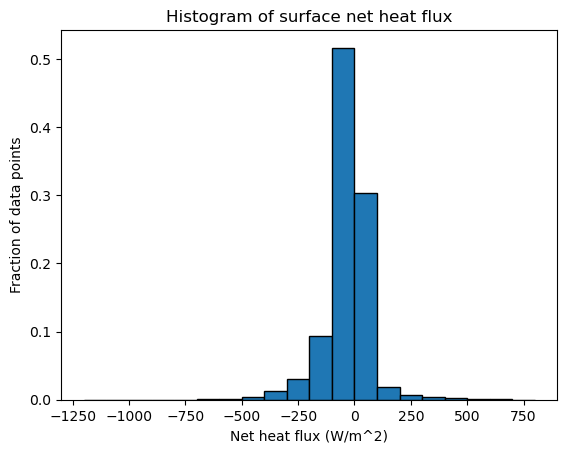

In [8]:
# historgram of net heat flux

# create bins
bins = np.arange(-1200, 900, 100)

# total number of data points
N = np.prod(df_heat["surface_net_heat_flux"].shape)

plt.hist(df_heat["surface_net_heat_flux"].values.flatten(), weights = np.ones(N) / N, bins=bins, edgecolor="black")

plt.xlabel("Net heat flux (W/m^2)")
plt.ylabel("Fraction of data points")
plt.title("Histogram of surface net heat flux")

# top 10% of net heat flux values

(0.0, 0.001)

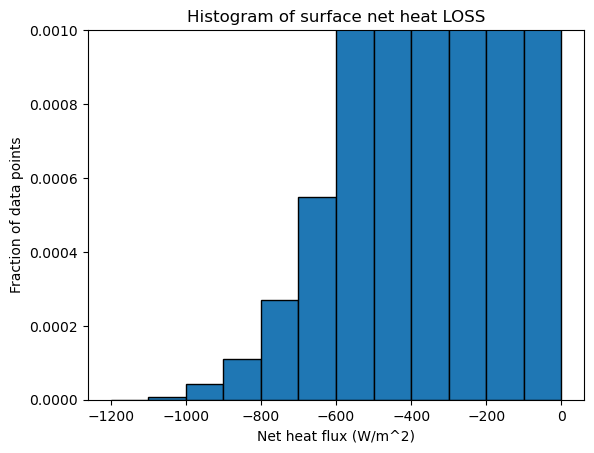

In [9]:
# historgram of net heat flux - zoom in on negative values

# create bins
bins = np.arange(-1200, 1, 100)

# total number of data points
N = np.prod(df_heat["surface_net_heat_flux"].shape)

plt.hist(df_heat["surface_net_heat_flux"].values.flatten(), weights = np.ones(N) / N, bins=bins, edgecolor="black")

plt.xlabel("Net heat flux (W/m^2)")
plt.ylabel("Fraction of data points")
plt.title("Histogram of surface net heat LOSS")
plt.ylim(0, 0.001)

# top 10% of net heat flux values

In [10]:
# calculate 1%, 0.1%, 0.01%, 0.001% percentiles of net heat flux
percentile_1 = np.nanpercentile(df_heat["surface_net_heat_flux"].values, 1)
percentile_01 = np.nanpercentile(df_heat["surface_net_heat_flux"].values, 0.1)
percentile_001 = np.nanpercentile(df_heat["surface_net_heat_flux"].values, 0.01)
percentile_0001 = np.nanpercentile(df_heat["surface_net_heat_flux"].values, 0.001)
print("1% percentile of net heat flux:", percentile_1, df_heat.surface_net_heat_flux.units, "corresponds to", 0.01*365*24*3, "h/year")
print("0.1% percentile of net heat flux:", percentile_01, df_heat.surface_net_heat_flux.units, "corresponds to", 0.001*365*24*3, "h/year")
print("0.01% percentile of net heat flux:", percentile_001, df_heat.surface_net_heat_flux.units)
print("0.001% percentile of net heat flux:", percentile_0001, df_heat.surface_net_heat_flux.units, "corresponds to", 0.0001*365*24*3, "h/year")

1% percentile of net heat flux: -365.04724 W m**-2 corresponds to 262.79999999999995 h/year
0.1% percentile of net heat flux: -597.8038 W m**-2 corresponds to 26.28 h/year
0.01% percentile of net heat flux: -836.3211 W m**-2
0.001% percentile of net heat flux: -988.38416 W m**-2 corresponds to 2.628 h/year


### Spatial Variability

In [11]:
# create a dataset with temporal statics of the net heat flux (mean, 90% percentile)
temporal_stats = xr.Dataset()
temporal_stats["mean_surface_net_heat_flux"] = df_heat["surface_net_heat_flux"].mean(dim=["time", "step"])
temporal_stats["percentile_1_surface_net_heat_flux"] = df_heat["surface_net_heat_flux"].quantile(0.01, dim=["time", "step"])


Text(0.5, 1.0, 'Mean surface net heat flux (W/m^2)')

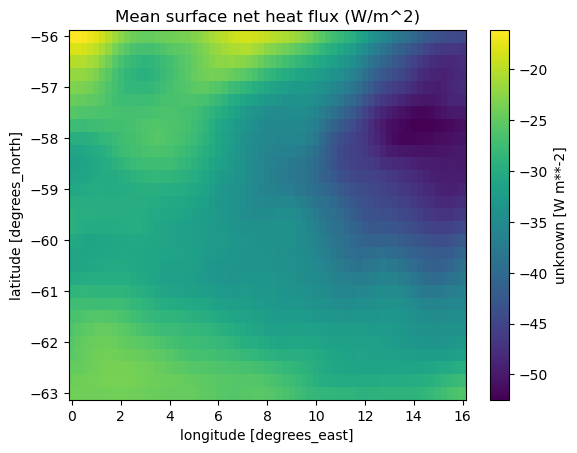

In [12]:
# plot mean net heat flux as a function of latitude and longitude
temporal_stats["mean_surface_net_heat_flux"].plot(x="longitude", y="latitude", cmap="viridis")
plt.title("Mean surface net heat flux (W/m^2)")

Text(0.5, 1.0, '1% percentile of surface net heat flux (W/m^2)')

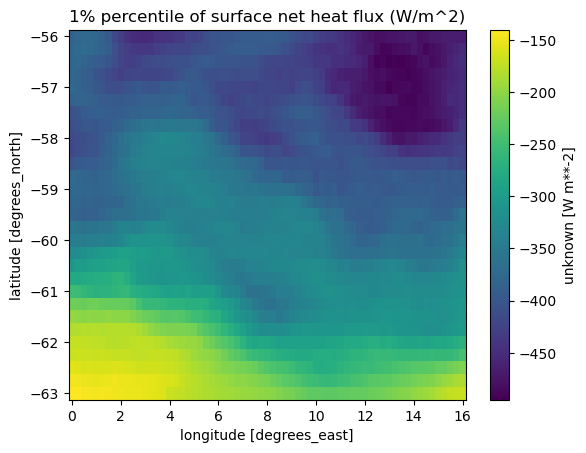

In [27]:
# plot 1 percentile as a funciton of lattitude and longitude
temporal_stats["percentile_1_surface_net_heat_flux"].plot(x="longitude", y="latitude", cmap="viridis")
plt.title("1% percentile of surface net heat flux (W/m^2)")

Text(0.5, 1.0, 'Standard deviation of surface net heat loss (W/m^2)')

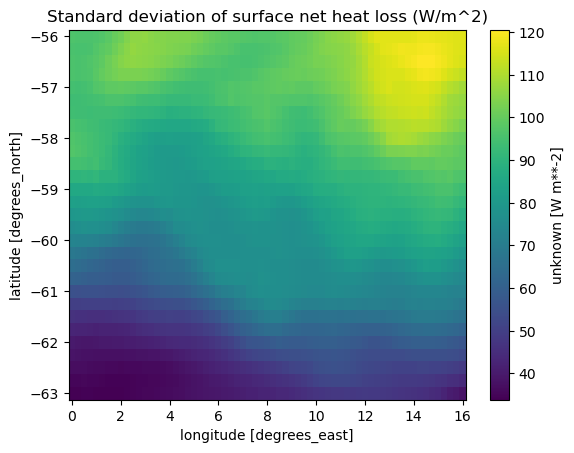

In [28]:
# stdev of heat loss events
heat_loss = df_heat["surface_net_heat_flux"].where(df_heat["surface_net_heat_flux"] < 0)
temporal_stats["stdev_heat_loss"] = heat_loss.std(dim=["time", "step"])
temporal_stats["stdev_heat_loss"].plot(x="longitude", y="latitude", cmap="viridis")
plt.title("Standard deviation of surface net heat loss (W/m^2)")

### Duration of Strong Heat Loss Events

## Sea Ice Concentration

In [ ]:
df_seaice

<xarray.Dataset> Size: 133MB
Dimensions:     (time: 17568, latitude: 29, longitude: 65)
Coordinates:
  * time        (time) datetime64[ns] 141kB 2007-06-01 ... 2010-11-30T23:00:00
  * latitude    (latitude) float64 232B -56.0 -56.25 -56.5 ... -62.75 -63.0
  * longitude   (longitude) float64 520B 0.0 0.25 0.5 0.75 ... 15.5 15.75 16.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
    valid_time  (time) datetime64[ns] 141kB 2007-06-01 ... 2010-11-30T23:00:00
Data variables:
    siconc      (time, latitude, longitude) float32 132MB 0.0 0.0 ... 0.3718
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-28T18:17 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# count NaNs
nan_count = np.isnan(df_seaice["siconc"].values).sum()
print(nan_count)
# total number of data points
N = np.prod(df_seaice["siconc"].shape)
print(nan_count/N*100, "% of data points are NaN")

0
0.0 % of data points are NaN


### Monthly averages - Ice Edge

In [ ]:
# take monthly mean - labeled with beginning of month
monthly_siconc = df_seaice.resample(time='MS').mean(skipna=True) # MS -> "month start"

# Drop any time steps where ALL variables are NaN
monthly_siconc = monthly_siconc.dropna(dim='time', how='all') # -> drops Dec-May

In [97]:
# count NaNs
nan_count = np.isnan(monthly_siconc["siconc"].values).sum()
print(nan_count)
# total number of data points
N = np.prod(monthly_siconc["siconc"].shape)
print(nan_count/N*100, "% of data points are NaN")

0
0.0 % of data points are NaN


#### Plot one winter:

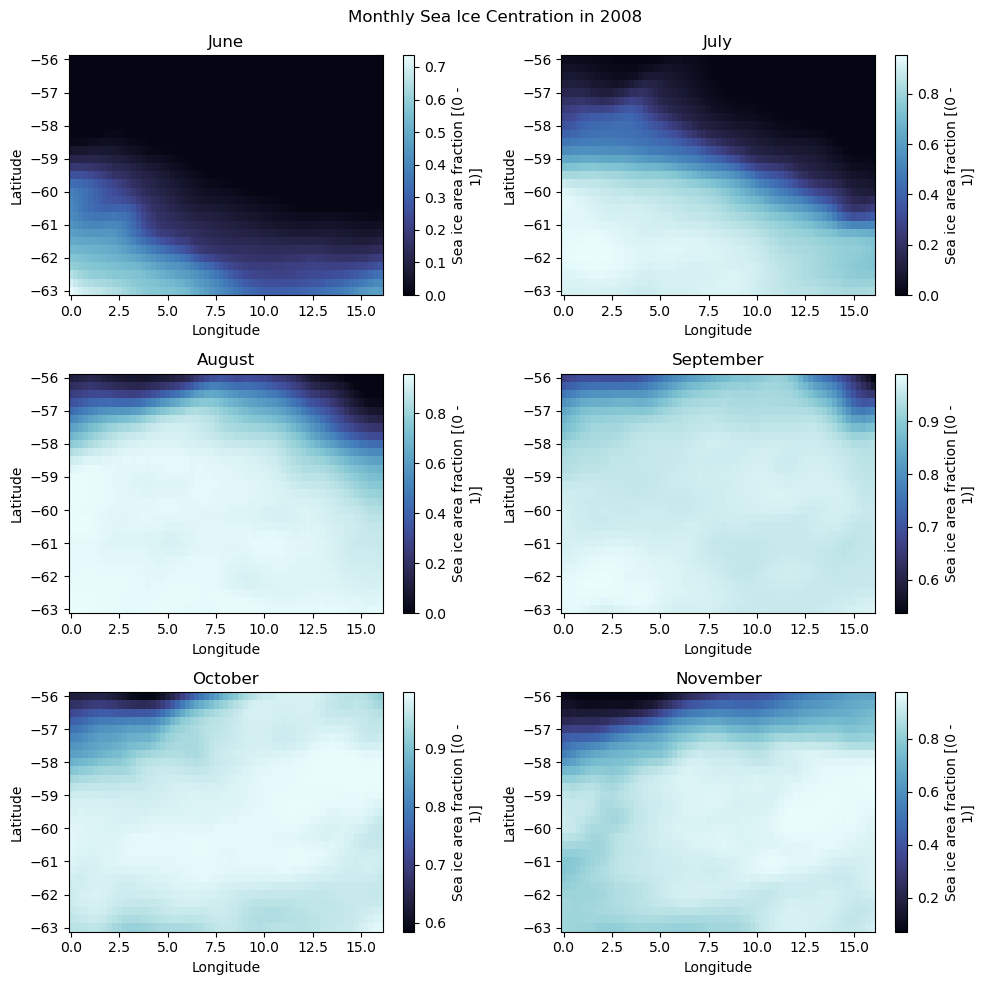

In [152]:
# spatial histogram for each month between June and November for a specific year
year = 2008
months = ["June", "July", "August", "September", "October", "November"]

fig, ax = plt.subplots(3,2, figsize=(10, 10))

for i in range(len(months)):    
    mask = (monthly_siconc.time.dt.month == i+6)  & (monthly_siconc.time.dt.year == year)
    data_month = monthly_siconc.sel(time = mask)

    row, col = divmod(i, 2)
    data_month.siconc.plot(ax=ax[row, col], x="longitude", y="latitude", cmap=cmo.ice)

    ax[row, col].set_xlabel('Longitude')
    ax[row, col].set_ylabel('Latitude')
    ax[row, col].set_title(months[i])

fig.suptitle(f"Monthly Sea Ice Centration in {year}")
plt.tight_layout()



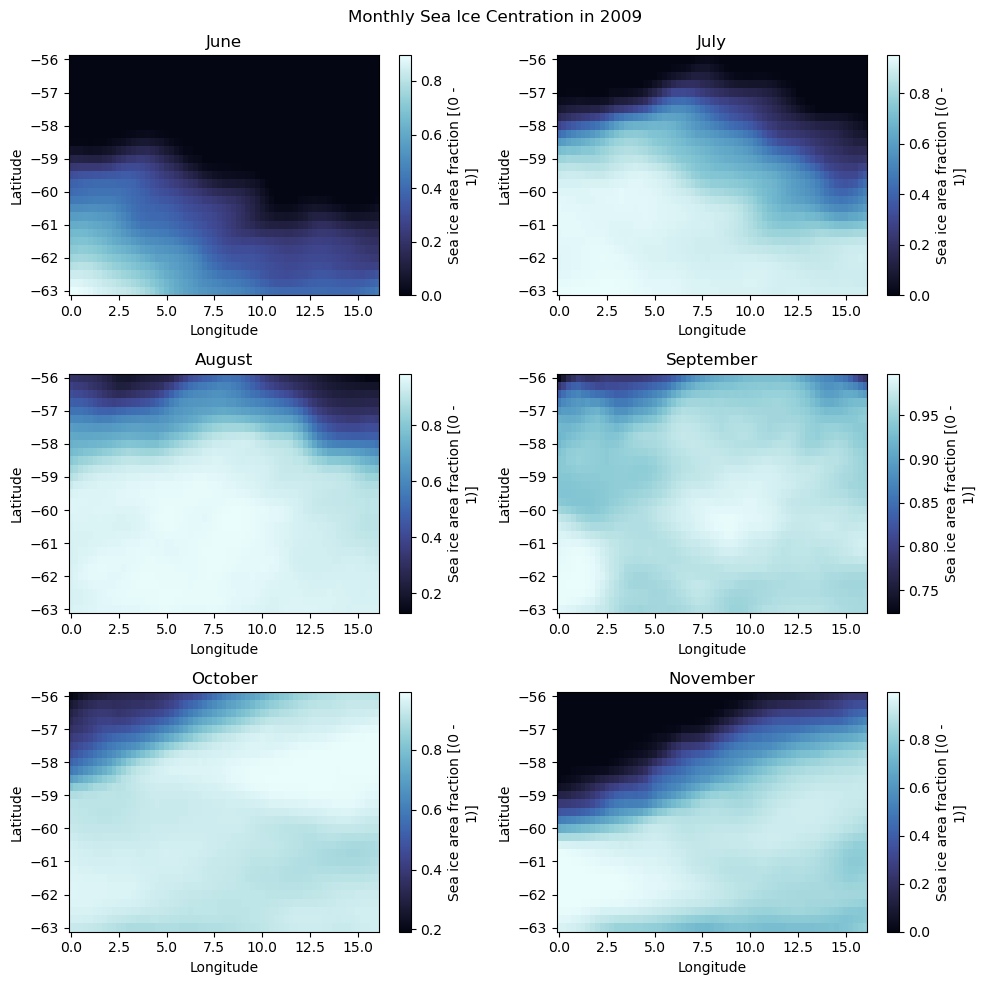

In [154]:
# spatial histogram for each month between June and November for a specific year
year = 2009
months = ["June", "July", "August", "September", "October", "November"]

fig, ax = plt.subplots(3,2, figsize=(10, 10))

for i in range(len(months)):    
    mask = (monthly_siconc.time.dt.month == i+6)  & (monthly_siconc.time.dt.year == year)
    data_month = monthly_siconc.sel(time = mask)

    row, col = divmod(i, 2)
    data_month.siconc.plot(ax=ax[row, col], x="longitude", y="latitude", cmap=cmo.ice)

    ax[row, col].set_xlabel('Longitude')
    ax[row, col].set_ylabel('Latitude')
    ax[row, col].set_title(months[i])

fig.suptitle(f"Monthly Sea Ice Centration in {year}")
plt.tight_layout()



# Estimate Open Water Fraction Heat Flux

If we assume that the heat flux over sea ice is close to zero, we can estimate the lead heat flux $Q_{lead}$ from the grid cell average heat flux $Q_{avg}$ and the sea ice concentration $c$:

$$ Q_{lead} = \frac{ 1}{1- c} Q_{avg} $$

We need to be aware that for sea ice concentrations close to 1 this goes to infinity.

Temporal structure: df_seaice and df_heat have not excactly the same time range. In each of the four years, df_heat starts 5h earlier and ends 7h later than our observation period '2007-06-01T00:00' to '2010-11-30T23:00'. Also, in df_heat the time variable is seperated into time and step. Therefore we need to restructure "surface_net_heat_flux" before adding it to df_seaice:

In [133]:
# Let's insert the total net heat flux into df_seaice, taking into account the different temporal structures

# 1. Flatten the 2D 'valid_time' coordinate into a 1D array of datetimes
# This gives us a clean list of 17,616 timestamps.
flat_times = df_heat.valid_time.values.ravel()

# 2. Create a new DataArray for your variable, manually assigning the flat time as its dimension
# We take the data, flatten it to match the time, and assign the new time coordinate.
var_name = 'surface_net_heat_flux'
heat_var_flat = df_heat[var_name].values.reshape(-1, df_heat[var_name].shape[-2], df_heat[var_name].shape[-1]) # Flatten time/step, keep lat/lon
heat_da = xr.DataArray(
    heat_var_flat,
    dims=['time', 'latitude', 'longitude'], # Adjust dims if your data has more
    coords={'time': flat_times, 'latitude': df_heat.latitude, 'longitude': df_heat.longitude},
    name=var_name
)

# 3. Reindex to match df_seaice and assign
df_seaice = df_seaice.assign(**{var_name: heat_da.reindex(time=df_seaice.time)})#

Let's estimate the open whater fraction of the heat flux and add it to df_seaice:

In [153]:
# calculate heat flux over open water fraction

# we do not want to perform this calculation for very high sea ice concentrations
c_max = 0.99
# set all higher values to nan
siconc_masked = df_seaice["siconc"].where(df_seaice["siconc"] <= c_max)
# calculate open water fraction heat flux
df_seaice["open_water_heatflux"] = df_seaice["surface_net_heat_flux"] / (1-siconc_masked)


Minimum value: -15065.279


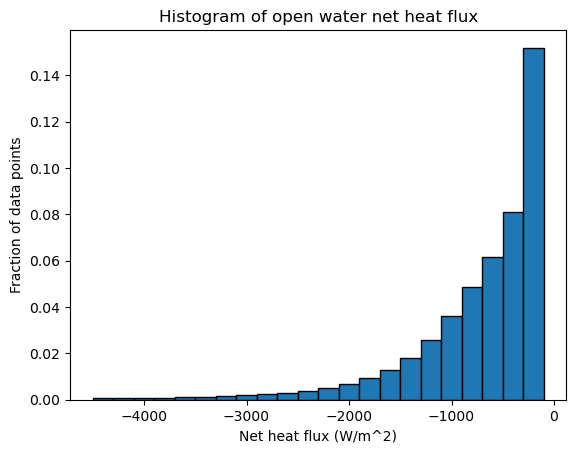

In [154]:
# histogram of open water heat flux

# create bins
bins = np.arange(-4500, 0, 200)

# total number of data points
N = np.prod(df_seaice["open_water_heatflux"].shape)

plt.hist(df_seaice["open_water_heatflux"].values.flatten(), weights = np.ones(N) / N, bins=bins, edgecolor="black")

plt.xlabel("Net heat flux (W/m^2)")
plt.ylabel("Fraction of data points")
plt.title("Histogram of open water net heat flux")

print("Minimum value:", df_seaice["open_water_heatflux"].min().values)
